<a href="https://colab.research.google.com/github/np03cs4s240161-dot/Concept-technology-of-AI/blob/main/Workshop10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Exercise1

In [ ]:

#PART 1
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.BytesIO(uploaded[fn]))

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def strict_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()

    clean_tokens = []
    for word in tokens:
        if word not in stop_words:
            stemmed_word = stemmer.stem(word)
            clean_tokens.append(stemmed_word)

    return " ".join(clean_tokens)

df['review'] = df['review'].apply(strict_preprocess)

y = df['sentiment'].map({'positive': 1, 'negative': 0})
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df['review'], y, test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

#PART 2

y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]


print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Saving IMDB Dataset.csv to IMDB Dataset.csv
User uploaded file "IMDB Dataset.csv" with length 66212309 bytes
Accuracy: 0.8555
Precision: 0.8691
Recall:    0.8397
F1-Score:  0.8541

Confusion Matrix:
[[4324  637]
 [ 808 4231]]

ROC-AUC Score: 0.9225


#Exercise2

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

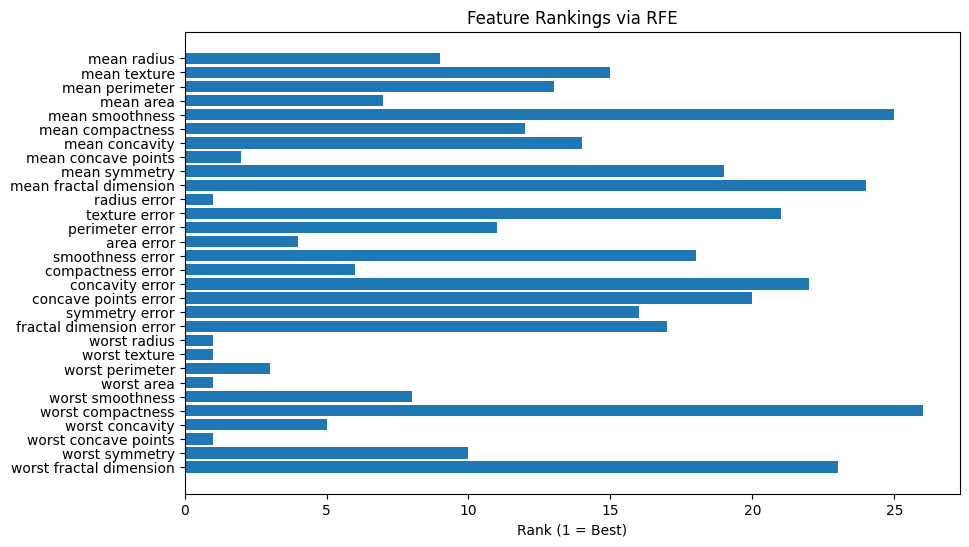

Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1-Score:  0.9790
ROC-AUC:   0.9977

Accuracy (All Features): 0.9737
Features: 3 -> Accuracy: 0.9649
Features: 7 -> Accuracy: 0.9737


In [ ]:

#PART 1
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.describe())

print("Missing values per column:", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#PART2

model = LogisticRegression(max_iter=5000)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

selected_features_mask = rfe.support_
selected_features = X.columns[selected_features_mask]
print("\nTop 5 Selected Features:", list(selected_features))

ranking = rfe.ranking_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, ranking)
plt.xlabel("Rank (1 = Best)")
plt.title("Feature Rankings via RFE")
plt.gca().invert_yaxis()
plt.show()

X_train_sel = rfe.transform(X_train_scaled)
X_test_sel = rfe.transform(X_test_scaled)

model_selected = LogisticRegression(max_iter=5000)
model_selected.fit(X_train_sel, y_train)

#PART3

y_pred_sel = model_selected.predict(X_test_sel)
y_proba_sel = model_selected.predict_proba(X_test_sel)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_sel):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sel):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_sel):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_sel):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_sel):.4f}")

model_all = LogisticRegression(max_iter=5000)
model_all.fit(X_train_scaled, y_train)
y_pred_all = model_all.predict(X_test_scaled)

print(f"\nAccuracy (All Features): {accuracy_score(y_test, y_pred_all):.4f}")

#PART4

for k in [3, 7]:
    rfe_exp = RFE(estimator=model, n_features_to_select=k)
    rfe_exp.fit(X_train_scaled, y_train)

    X_train_exp = rfe_exp.transform(X_train_scaled)
    X_test_exp = rfe_exp.transform(X_test_scaled)
    model_exp = LogisticRegression(max_iter=5000).fit(X_train_exp, y_train)

    acc = accuracy_score(y_test, model_exp.predict(X_test_exp))
    print(f"Features: {k} -> Accuracy: {acc:.4f}")
